In [ ]:
# initialize box
# initialize surface charge
# initialize galvanin positions on membrane
# initialize ions from pH + salt concentration

# for each timestep:
#     compute zeta from pH
#     compute Debye length from ionic strength
#     compute EOF profile u(y)

#     for each ion:
#         drift = mu_i * q_i * E
#         flow  = u(y)
#         noise = sqrt(2Ddt) * randn
#         update position

#     for each galvanin:
#         drift_x = mu_g * q_eff * E_x
#         noise_x = sqrt(2Dgdt) * randn
#         update x only

#     enforce boundaries
#     render

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML
from datetime import date

today = date.today().strftime("%Y%m%d")

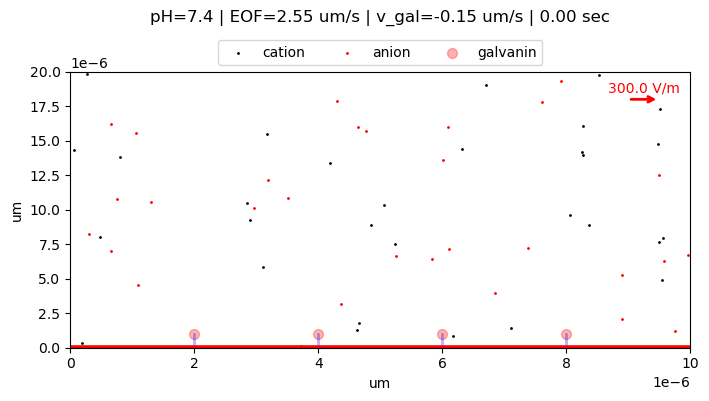

In [8]:
n_frames = 100

Lx = 10e-6      # m, 10um (size of zebrafish keratocyte)
Ly = 20e-6      # m, 20um
dt = 0.2        # s
E = 300.0       # V/m = 3 V/cm = 300 mV/mm

# ===============
#      init
# ===============
n_cation = 30       # +
n_anion = 30        # -

x_cation0 = np.random.rand(n_cation) * Lx
y_cation0 = np.random.rand(n_cation) * Ly

x_anion0 = np.random.rand(n_anion) * Lx
y_anion0 = np.random.rand(n_anion) * Ly

x_gal0 = np.array([2e-6, 4e-6, 6e-6, 8e-6], dtype=float)
y_gal0 = np.array([1e-6, 1e-6, 1e-6, 1e-6], dtype=float)

# ==== electro-osmosis ====
pH = 7.4
def zeta_from_pH(pH):
    return -0.005 * (pH - 5.0)  # V

eps = 7.08e-10              # F/m
eta = 1e-3                  # Pa s
zeta = zeta_from_pH(pH)     # -0.012 V = -12mV

v_eof = -(eps * zeta / eta) * E     # m/s

# ==== electrophoresis =====
mu_cation = 5e-8    # electrophoretic mobility of small inorganic cation (10-8 ~ 10-7 m^2/(V⋅s))
mu_anion = -5e-8    # electrophoretic mobility of small inorganic anion (10-8 ~ 10-7 m^2/(V⋅s))
mu_gal = -5e-10     # assuming small toy parameter

v_cation = mu_cation * E + v_eof
v_anion = mu_anion * E + v_eof
v_gal = mu_gal * E  # -5e-10 x 300 = -1.5e-7 m/s = -0.15 um/s = -9 um/min, ignore EOF for now

# ==== Brownian Diffusion ====
D_gal = 5e-14
gal_noise = np.sqrt(2 * D_gal * dt) * np.random.randn(n_frames, len(x_gal0))

# ====================
#      Simulation
# ====================
fig, ax = plt.subplots(figsize = (8,4))
fig.subplots_adjust(top=0.80)

scat_cation = ax.scatter(x_cation0, y_cation0, label = 'cation', color = "black", s=1)
scat_anion = ax.scatter(x_anion0, y_anion0, label = 'anion', color="red", s=1)
scat_gal = ax.scatter(x_gal0, y_gal0, label = 'galvanin', color="red", s=50, alpha=0.3)
line_gal = [ax.plot([x, x], [0, y], color='blue', linewidth=2, alpha=0.3)[0]
             for x, y in zip(x_gal0, y_gal0)]
ax.annotate(
    f"",
    xy=(9.5e-6, 18e-6),     # arrow head
    xytext=(9e-6, 18e-6),   # arrow tail
    arrowprops=dict(arrowstyle="->", color="red", lw=2)
)
ax.text(
    9.25e-6, 18.5e-6, 
    f"{E} V/m",
    color="red",
    ha="center"
)
ax.axhline(0, color = "red", linewidth=4)
ax.ticklabel_format(style='sci', axis='y', scilimits=(-6, -6))
ax.ticklabel_format(style='sci', axis='x', scilimits=(-6, -6))
ax.set_xlim(0, Lx)
ax.set_xlabel("um")
ax.set_ylim(0, Ly)
ax.set_ylabel("um")
ax.legend(bbox_to_anchor=(0.5, 1.14), loc='upper center', ncol=3)
title = ax.set_title("", y = 1.15)

def init():
    global x_cation, y_cation, x_anion, y_anion, x_gal, y_gal

    x_cation = x_cation0.copy()
    y_cation = y_cation0.copy()
    x_anion = x_anion0.copy()
    y_anion = y_anion0.copy()
    x_gal = x_gal0.copy()
    y_gal = y_gal0.copy()

    scat_cation.set_offsets(np.c_[x_cation, y_cation])
    scat_anion.set_offsets(np.c_[x_anion, y_anion])
    scat_gal.set_offsets(np.c_[x_gal, y_gal])

    for line, xh, yh in zip(line_gal, x_gal, y_gal):
        line.set_data([xh, xh], [0, yh])

    title.set_text(
        f"pH={pH} | EOF={v_eof*1e6:.2f} um/s | v_gal={v_gal*1e6:.2f} um/s | 0.00 sec"
    )

    return [scat_cation, scat_anion, scat_gal, title, *line_gal]

def update(i):
    global x_cation, x_anion, x_gal
    
    # ==== update positions =====
    if i > 0:
        x_cation = (x_cation + v_cation * dt) % Lx      # Cation (+) moves toward cathode (-) % loop
        x_anion = (x_anion + v_anion * dt) % Lx         # Anion (-) moves toward anode (+) % loop
        x_gal = (x_gal + v_gal * dt) + gal_noise[i]
        x_gal = np.clip(x_gal, 0, Lx)
    
    scat_cation.set_offsets(np.c_[x_cation, y_cation])
    scat_anion.set_offsets(np.c_[x_anion, y_anion])
    scat_gal.set_offsets(np.c_[x_gal, y_gal])
    for line, xh, yh in zip(line_gal, x_gal, y_gal):
        line.set_data([xh, xh], [0, yh])

    # ==== update title ====
    title.set_text(
        f"pH{pH} | EOF={v_eof*1e6:.2f} um/s "
        f"| v_gal={v_gal*1e6:.2f} um/s | {i * dt:.2f} sec"
    )
    return [scat_cation, scat_anion, scat_gal, title, *line_gal]

anim = FuncAnimation(fig, update, frames=n_frames, init_func = init, interval=50, blit=False)
writer = FFMpegWriter(fps=20)
anim.save(f"galvanotaxis_simulation_{today}.gif", writer=writer)
HTML(anim.to_jshtml())